In [1]:
import probcs
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle

In [2]:
from probcs.datajoint.exc_tables import ExcConfig, ExcResult, schema

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
[2023-11-30 13:25:37,551][INFO]: Connecting sshrinivasan@134.76.19.44:3306
[2023-11-30 13:25:37,656][INFO]: Connected sshrinivasan@134.76.19.44:3306


In [4]:
result = ExcConfig() * ExcResult()

In [5]:
result

config_id,seed random seed,g_dim dimensionality of G,g_prob Bernoulli probability of g_i being 1,x_sigma Laplace distribution scale parameter for x,i_sigma Normal distribution scale parameter for i,patterns_offset offset to increase cosine similarity between patterns,n_tune number of tuning samples,n_draws number of samples to draw,n_chains number of chains,n_cores number of cores to use,all_idata,all_stimuli,all_g_means,all_g_means_sde,all_center_x_means,all_center_x_means_sde,all_center_x_perc_change_means,all_center_x_perc_change_means_sde
26dc2ce7668fb9a6fbb7a215dc91a02f,42,4,0.4,0.1,5.0,0.0,500,500,4,4,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
375790809d6424779c4422f639d9c60b,42,4,0.5,0.1,20.0,0.0,500,500,1,1,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
60aeef325e38e4e13f183731e076d363,42,4,0.2,0.1,20.0,0.0,500,500,4,4,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
6be2bcfa4678223960bd740eb55dc90b,42,4,0.4,0.1,10.0,0.0,500,500,4,4,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
90e806dca37a81c9c01e0f12542b026b,42,4,0.5,0.1,10.0,0.0,500,500,1,1,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
cdd63f609c9c0cfa8de8ac3ef6f1f27c,42,4,0.2,0.1,5.0,0.0,500,500,4,4,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
d40f762105f782ac77fc96b4735442f8,42,4,0.4,0.1,20.0,0.0,500,500,4,4,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
e7b858219c6b3db53ac583905ae1b3b7,42,4,0.5,0.1,5.0,0.0,500,500,1,1,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
ed4ae07802961b837a355ba3d54ff503,42,4,0.2,0.1,10.0,0.0,500,500,4,4,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=


In [6]:
df = result.fetch(download_path="/tmp", as_dict=True)

In [18]:
with open(df[0]["all_idata"], "rb") as f:
    all_idata = pickle.load(f)

In [13]:
row["all_center_x_perc_change_means"]

[[0.0017423496375991443,
  -0.05914344531063485,
  -0.1413327779376266,
  0.047005601252858464],
 [-0.05397756162636691,
  0.01584100602167709,
  -0.10237629746082338,
  -0.05050655893531366],
 [0.2139392612219469,
  0.11865987837593152,
  0.20587804855818523,
  0.12290568780185021],
 [0.03838637033604129,
  0.057318920858595676,
  -0.00875232642067347,
  -0.0797874678382805]]

In [16]:
g_dim

4

In [15]:
x_perc_change_means

[[0.0017423496375991443,
  -0.05914344531063485,
  -0.1413327779376266,
  0.047005601252858464],
 [-0.05397756162636691,
  0.01584100602167709,
  -0.10237629746082338,
  -0.05050655893531366],
 [0.2139392612219469,
  0.11865987837593152,
  0.20587804855818523,
  0.12290568780185021],
 [0.03838637033604129,
  0.057318920858595676,
  -0.00875232642067347,
  -0.0797874678382805]]

In [21]:
enumerate(range(g_dim))

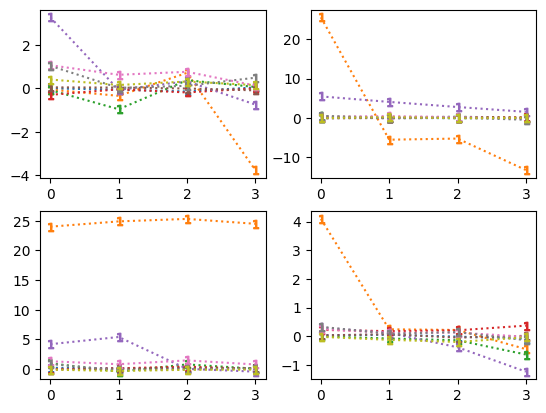

In [34]:
fig, axs = plt.subplots(nrows=2, ncols=2, dpi=300)
for row, marker in zip(df, markers):
    x_perc_change_means = row["all_center_x_perc_change_means"]
    x_perc_change_means_sde = row["all_center_x_perc_change_means_sde"]
    for dim, ax in enumerate(axs.flatten()):
        ax.plot(x_perc_change_means[dim], linestyle="dotted", marker="$1$")

In [ ]:
fig, axs = plt.subplots(2, 2, dpi=300)
for row in df:
    g_dim = row['g_dim']
    for dim, ax in zip(g_dim, axs.flatten()):
        

In [26]:
df[1]["all_center_x_perc_change_means"]

[[-0.05428703717872319,
  -0.34142983199636284,
  0.7161634387735504,
  -3.7621121118146057],
 [25.596140672731476,
  -5.563853069241302,
  -5.273527396292884,
  -13.288824151441725],
 [24.014246957568474,
  24.904205034899903,
  25.321975257545677,
  24.496459050533794],
 [4.090688618529099,
  0.2461646743343304,
  0.22296853080756898,
  -0.4430814188954231]]

In [10]:
df[0]["all_center_x_perc_change_means_sde"]

[[0.055381512236715134,
  0.020257068589240913,
  0.030852465975599964,
  0.06966039312324762],
 [0.12618403553940546,
  0.12167639617419147,
  0.1230264600808895,
  0.11987254921739289],
 [0.07228491134491424,
  0.09453533911728863,
  0.09782591919864163,
  0.05844668647675758],
 [0.038788564798945394,
  0.05999383924207019,
  0.04109255709623727,
  0.04699911386855805]]

In [8]:
df[0]["all_center_x_perc_change_means"]

[[0.0017423496375991443,
  -0.05914344531063485,
  -0.1413327779376266,
  0.047005601252858464],
 [-0.05397756162636691,
  0.01584100602167709,
  -0.10237629746082338,
  -0.05050655893531366],
 [0.2139392612219469,
  0.11865987837593152,
  0.20587804855818523,
  0.12290568780185021],
 [0.03838637033604129,
  0.057318920858595676,
  -0.00875232642067347,
  -0.0797874678382805]]

In [5]:
fig, axs = plt.subplots()
for row in df:
    

array([('26dc2ce7668fb9a6fbb7a215dc91a02f', 42, 4, 0.4, 0.1,  5., 0., 500, 500, 4, 4, '26dc2ce7668fb9a6fbb7a215dc91a02f_idata.pkl', '26dc2ce7668fb9a6fbb7a215dc91a02f_stimuli.pkl', list([[array([0., 0., 0., 0.]), array([0., 0., 0., 0.]), array([0., 0., 0., 0.]), array([0., 0., 0., 0.]), array([0., 0., 0., 0.])], [array([0., 0., 0., 0.]), array([0., 0., 0., 0.]), array([0., 0., 0., 0.]), array([0., 0., 0., 0.]), array([0., 0., 0., 0.])], [array([0., 0., 0., 0.]), array([0., 0., 0., 0.]), array([0., 0., 0., 0.]), array([0., 0., 0., 0.]), array([0., 0., 0., 0.])], [array([0., 0., 0., 0.]), array([0.    , 0.    , 0.    , 0.1515]), array([0., 0., 0., 0.]), array([0., 0., 0., 0.]), array([0., 0., 0., 0.])]]), list([[array([0., 0., 0., 0.]), array([0., 0., 0., 0.]), array([0., 0., 0., 0.]), array([0., 0., 0., 0.]), array([0., 0., 0., 0.])], [array([0., 0., 0., 0.]), array([0., 0., 0., 0.]), array([0., 0., 0., 0.]), array([0., 0., 0., 0.]), array([0., 0., 0., 0.])], [array([0., 0., 0., 0.]), ar

In [18]:
result_dict = (result & "config_id = '6be2bcfa4678223960bd740eb55dc90b'").fetch1(
    download_path="/tmp/"
)

In [19]:
result_dict.keys()

dict_keys(['config_id', 'seed', 'g_dim', 'g_prob', 'x_sigma', 'i_sigma', 'patterns_offset', 'n_tune', 'n_draws', 'n_chains', 'n_cores', 'all_idata', 'all_stimuli', 'all_g_means', 'all_g_means_sde', 'all_center_x_means', 'all_center_x_means_sde', 'all_center_x_perc_change_means', 'all_center_x_perc_change_means_sde'])

In [20]:
result_dict["all_center_x_perc_change_means"]

[[-0.2961752447910132,
  -0.04028727888012944,
  -0.18569886908022737,
  0.0002768884991614755],
 [0.23895333696071164,
  0.07927010179965796,
  0.07866054423182532,
  0.12664032297381578],
 [0.0024858399233616893,
  0.13530082162841203,
  0.4063004882015348,
  0.05519268445148054],
 [0.2261662730990704,
  0.18223145651734335,
  0.21102133675138238,
  0.3736837710027082]]

In [21]:
result_dict["all_g_means"]

[[array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.])],
 [array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.])],
 [array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.])],
 [array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.])]]

In [22]:
result_dict["all_g_means_sde"]

[[array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.])],
 [array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.])],
 [array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.])],
 [array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.]),
  array([0., 0., 0., 0.])]]